In [1]:
!pip install pystac_client planetary_computer stackstac rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


40.581314, -101.959920

40.596109, -101.940436


Kelirav Farms LLC

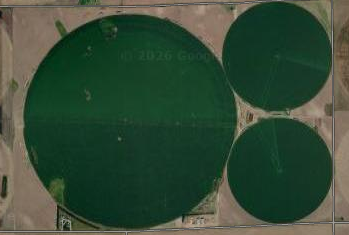

In [2]:
import os
import json
import time
import datetime
from datetime import timedelta
import pystac_client
import planetary_computer
import stackstac
import numpy as np
import xarray as xr
import rioxarray

# ==========================================
# 1. CONFIGURACIÓN DE PARÁMETROS GENERALES
# ==========================================
BBOX = [-101.959920, 40.581314, -101.940436, 40.596109]
FECHA_INICIO = "2025-06-01"
FECHA_FIN = "2026-02-28"

MAX_NUBES_GLOBAL = 60.0
MAX_NUBES_LOCAL = 20.0
CARPETA_RAIZ = "data_heavy"

bbox_id = f"bbox_{BBOX[0]}_{BBOX[1]}_{BBOX[2]}_{BBOX[3]}".replace(".", "_")
carpeta_trabajo = os.path.join(CARPETA_RAIZ, bbox_id)
archivo_metadata = os.path.join(carpeta_trabajo, "pipeline_metadata.json")

os.makedirs(carpeta_trabajo, exist_ok=True)

# ==========================================
# 2. GESTIÓN DEL ARCHIVO DE CONTROL (CHECKPOINT)
# ==========================================
if os.path.exists(archivo_metadata):
    with open(archivo_metadata, "r") as f:
        metadata = json.load(f)
    print(f" -> Registro encontrado. Reanudando proceso para el área {bbox_id}...")
else:
    print(f" -> Creando nuevo registro de datos para el área {bbox_id}...")
    metadata = {
        "configuracion": {
            "bbox": BBOX,
            "max_nubes_local": MAX_NUBES_LOCAL,
            "indice": "NDWI"
        },
        "historial_fechas": {}
    }

def guardar_progreso():
    with open(archivo_metadata, "w") as f:
        json.dump(metadata, f, indent=4)

# ==========================================
# 3. CONEXIÓN AL CATÁLOGO STAC
# ==========================================
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# ==========================================
# 3.5 DESCARGA ÚNICA DEL MODELO DE ELEVACIÓN (SRTM)
# ==========================================
archivo_dem = os.path.join(carpeta_trabajo, "dem_srtm.tif")

if not os.path.exists(archivo_dem):
    print("\n[INFO] El DEM no existe localmente. Descargando datos SRTM (NASADEM)...")
    try:
        search_dem = catalog.search(
            collections=["nasadem"],
            bbox=BBOX
        )
        items_dem = list(search_dem.item_collection())

        if items_dem:
            # Usamos los mismos parámetros epsg y resolution para que la malla coincida
            cubo_dem = stackstac.stack(
                items_dem,
                bounds_latlon=BBOX,
                assets=["elevation"],
                epsg=3857,
                resolution=30,
                chunksize=256
            )
            # Computar y limpiar
            dem_datos = cubo_dem.compute()
            if 'spec' in dem_datos.attrs: del dem_datos.attrs['spec']
            coordenadas_esenciales = ['time', 'y', 'x', 'spatial_ref']
            coordenadas_basura = [coord for coord in dem_datos.coords if coord not in coordenadas_esenciales]
            dem_limpio = dem_datos.drop_vars(coordenadas_basura)

            # Guardamos el DEM. Tomamos el time=0 o lo colapsamos si es necesario
            dem_limpio.isel(time=0).rio.to_raster(archivo_dem)
            print("   -> ¡DEM guardado exitosamente!")
        else:
            print("   [Error] No se encontró cobertura DEM para este BBox.")
    except Exception as e:
        print(f"   [Error] Fallo al descargar el DEM: {e}")
else:
    print(f"\n[INFO] DEM ya existe en la caché local: {archivo_dem}")


# Generar lista de días
fecha_actual = datetime.datetime.strptime(FECHA_INICIO, "%Y-%m-%d")
fecha_limite = datetime.datetime.strptime(FECHA_FIN, "%Y-%m-%d")
dias_a_procesar = []

while fecha_actual <= fecha_limite:
    dias_a_procesar.append(fecha_actual.strftime("%Y-%m-%d"))
    fecha_actual += timedelta(days=1)

print(f"Total de días en el rango seleccionado: {len(dias_a_procesar)} días.")

# ==========================================
# 4. CICLO ROBUSTO DE INGESTIÓN (DÍA A DÍA - NDWI)
# ==========================================
for dia in dias_a_procesar:
    if dia in metadata["historial_fechas"]:
        estado = metadata["historial_fechas"][dia]["estado"]
        if estado in ["descargado", "descartado_por_nubes", "no_hay_imagenes", "rechazo_local"]:
            continue

    print(f"\n----------------------------------------")
    print(f"Procesando fecha: {dia}...")
    rango_dia = f"{dia}/{dia}"

# 4.1 Búsqueda en STAC (Versión Anti-Rate-Limit)
    items = []
    for intento in range(1, 4):
        try:
            search = catalog.search(
                collections=["sentinel-2-l2a"],
                bbox=BBOX,
                datetime=rango_dia
            )
            items = list(search.item_collection())
            break
        except Exception as e:
            error_msg = str(e).lower()
            if "rate limit" in error_msg or "429" in error_msg:
                # Si Microsoft nos bloquea por velocidad, esperamos 30 segundos obligatorios para enfriar la IP
                print(f"   [ALERTA] Límite de peticiones excedido (Rate Limit). Enfriando conexión por 30 segundos... (Intento {intento}/3)")
                time.sleep(30)
            else:
                print(f"   [Aviso] Error de catálogo (Intento {intento}/3): {e}")
                time.sleep(10)

    if not items:
        print(f"   -> No hay órbitas para esta fecha.")
        metadata["historial_fechas"][dia] = {"estado": "no_hay_imagenes", "timestamp": str(datetime.datetime.now())}
        guardar_progreso()
        continue

    # Filtrar primero por el límite global amplio
    items_validos = [i for i in items if i.properties["eo:cloud_cover"] <= MAX_NUBES_GLOBAL]

    if not items_validos:
        print(f"   [LOG] RECHAZO GLOBAL: Todas las imágenes del día superan el {MAX_NUBES_GLOBAL}% general.")
        metadata["historial_fechas"][dia] = {
            "estado": "descartado_por_nubes",
            "timestamp": str(datetime.datetime.now())
        }
        guardar_progreso()
        continue

    mejor_item = sorted(items_validos, key=lambda x: x.properties["eo:cloud_cover"])[0]
    nubes_globales = mejor_item.properties["eo:cloud_cover"]
    print(f"   -> Escena seleccionada. Nubes Globales: {nubes_globales:.2f}%")

    # 4.2 REVISIÓN LOCAL DE NUBES (Banda SCL)
    print("   -> Descargando banda SCL para revisión exacta...")
    try:
        cubo_scl = stackstac.stack(
            [mejor_item],
            bounds_latlon=BBOX,
            assets=["SCL"],
            epsg=3857,
            resolution=30,
            chunksize=256
        )
        scl_datos = cubo_scl.compute()
        matriz_scl = scl_datos.values

        pixeles_validos = np.count_nonzero(~np.isnan(matriz_scl))
        pixeles_nubes = np.count_nonzero(np.isin(matriz_scl, [3, 8, 9, 10]))

        if pixeles_validos == 0:
            porcentaje_local = 100.0
        else:
            porcentaje_local = (pixeles_nubes / pixeles_validos) * 100

        print(f"   -> Nubes Locales exactas (en el BBox): {porcentaje_local:.2f}%")

        if porcentaje_local > MAX_NUBES_LOCAL:
            print(f"   [LOG] RECHAZO LOCAL: Excede el límite de {MAX_NUBES_LOCAL}% en tu área.")
            metadata["historial_fechas"][dia] = {
                "estado": "rechazo_local",
                "nubes_globales": nubes_globales,
                "nubes_locales": porcentaje_local,
                "timestamp": str(datetime.datetime.now())
            }
            guardar_progreso()
            continue

    except Exception as e:
        print(f"   [Error] Fallo al evaluar nubes locales: {e}")
        continue

    # 4.3 DESCARGA FINAL DE DATOS NDWI (B03 y B08)
    nombre_archivo_tif = os.path.join(carpeta_trabajo, f"ndwi_{dia}.tif")
    print(f"   -> ¡Área limpia! Descargando bandas para NDWI...")

    descarga_exitosa = False
    for intento in range(1, 4):
        try:
            cubo_indices = stackstac.stack(
                [mejor_item],
                bounds_latlon=BBOX,
                assets=["B08", "B11"], # NIR y SWIR para NDWI de Gao (NDMI)
                epsg=3857,
                resolution=10, # B08 es 10m, B11 es 20m, stackstac lo ajusta a 10m automáticamente
                chunksize=256
            )

            # Fórmula NDWI de Gao = (NIR - SWIR) / (NIR + SWIR)
            nir = cubo_indices.sel(band="B08")
            swir = cubo_indices.sel(band="B11")
            ndwi = (nir - swir) / (nir + swir)

            ndwi_datos = ndwi.compute()

            # Limpieza de metadatos
            if 'spec' in ndwi_datos.attrs: del ndwi_datos.attrs['spec']
            coordenadas_esenciales = ['time', 'y', 'x', 'spatial_ref']
            coordenadas_basura = [coord for coord in ndwi_datos.coords if coord not in coordenadas_esenciales]
            ndwi_limpio = ndwi_datos.drop_vars(coordenadas_basura)

            # Guardado TIF
            ndwi_limpio.isel(time=0).rio.to_raster(nombre_archivo_tif)

            descarga_exitosa = True
            print(f"   ¡Guardado exitoso!: {nombre_archivo_tif}")
            break
        except Exception as e:
            print(f"   [Error] Fallo en descarga final (Intento {intento}/3): {e}")
            time.sleep(10)

    # 4.4 REGISTRO DE ÉXITO
    if descarga_exitosa:
        metadata["historial_fechas"][dia] = {
            "estado": "descargado",
            "nubes_globales": nubes_globales,
            "nubes_locales": round(porcentaje_local, 2),
            "item_id": mejor_item.id,
            "archivo_local": nombre_archivo_tif,
            "timestamp": str(datetime.datetime.now())
        }
        guardar_progreso()
    else:
        print(f"   [Alerta] No se pudo descargar el archivo final para el {dia}.")

print("\n==========================================")
print("¡Pipeline finalizado o pausado correctamente!")
print("==========================================")

 -> Creando nuevo registro de datos para el área bbox_-101_95992_40_581314_-101_940436_40_596109...

[INFO] El DEM no existe localmente. Descargando datos SRTM (NASADEM)...


   -> ¡DEM guardado exitosamente!
Total de días en el rango seleccionado: 273 días.

----------------------------------------
Procesando fecha: 2025-06-01...
   -> Escena seleccionada. Nubes Globales: 0.00%
   -> Descargando banda SCL para revisión exacta...


   -> Nubes Locales exactas (en el BBox): 0.00%
   -> ¡Área limpia! Descargando bandas para NDWI...


   ¡Guardado exitoso!: data_heavy/bbox_-101_95992_40_581314_-101_940436_40_596109/ndwi_2025-06-01.tif

----------------------------------------
Procesando fecha: 2025-06-02...
   -> No hay órbitas para esta fecha.

----------------------------------------
Procesando fecha: 2025-06-03...
   [LOG] RECHAZO GLOBAL: Todas las imágenes del día superan el 60.0% general.

----------------------------------------
Procesando fecha: 2025-06-04...
   -> No hay órbitas para esta fecha.

----------------------------------------
Procesando fecha: 2025-06-05...
   [LOG] RECHAZO GLOBAL: Todas las imágenes del día superan el 60.0% general.

----------------------------------------
Procesando fecha: 2025-06-06...
   [LOG] RECHAZO GLOBAL: Todas las imágenes del día superan el 60.0% general.

----------------------------------------
Procesando fecha: 2025-06-07...
   -> No hay órbitas para esta fecha.

----------------------------------------
Procesando fecha: 2025-06-08...
   -> Escena seleccionada. Nubes

   -> Nubes Locales exactas (en el BBox): 0.00%
   -> ¡Área limpia! Descargando bandas para NDWI...


...

   ¡Guardado exitoso!: data_heavy/bbox_-101_95992_40_581314_-101_940436_40_596109/ndwi_2026-02-21.tif

----------------------------------------
Procesando fecha: 2026-02-22...
   -> No hay órbitas para esta fecha.

----------------------------------------
Procesando fecha: 2026-02-23...
   [LOG] RECHAZO GLOBAL: Todas las imágenes del día superan el 60.0% general.

----------------------------------------
Procesando fecha: 2026-02-24...
   -> No hay órbitas para esta fecha.

----------------------------------------
Procesando fecha: 2026-02-25...
   -> No hay órbitas para esta fecha.

----------------------------------------
Procesando fecha: 2026-02-26...
   -> Escena seleccionada. Nubes Globales: 0.00%
   -> Descargando banda SCL para revisión exacta...


   -> Nubes Locales exactas (en el BBox): 0.00%
   -> ¡Área limpia! Descargando bandas para NDWI...


   ¡Guardado exitoso!: data_heavy/bbox_-101_95992_40_581314_-101_940436_40_596109/ndwi_2026-02-26.tif

----------------------------------------
Procesando fecha: 2026-02-27...
   -> No hay órbitas para esta fecha.

----------------------------------------
Procesando fecha: 2026-02-28...
   -> Escena seleccionada. Nubes Globales: 0.00%
   -> Descargando banda SCL para revisión exacta...


   -> Nubes Locales exactas (en el BBox): 0.00%
   -> ¡Área limpia! Descargando bandas para NDWI...


   ¡Guardado exitoso!: data_heavy/bbox_-101_95992_40_581314_-101_940436_40_596109/ndwi_2026-02-28.tif

¡Pipeline finalizado o pausado correctamente!


In [3]:
!pip install contextily imageio rioxarray matplotlib

In [4]:
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import rioxarray
import imageio.v2 as imageio

# ==========================================
# 1. CONFIGURACIÓN (Usa tu carpeta existente)
# ==========================================
CARPETA_RAIZ = "data_heavy"
carpetas_disponibles = [f for f in os.listdir(CARPETA_RAIZ) if os.path.isdir(os.path.join(CARPETA_RAIZ, f)) and f.startswith("bbox_")]
carpeta_elegida = carpetas_disponibles[0]
carpeta_trabajo = os.path.join(CARPETA_RAIZ, carpeta_elegida)

carpeta_frames = os.path.join(carpeta_trabajo, "frames_dobles")
os.makedirs(carpeta_frames, exist_ok=True)

print(f"-> Trabajando con: {carpeta_elegida}")

# Leer el BBOX del metadata para las coordenadas del grid
archivo_metadata = os.path.join(carpeta_trabajo, "pipeline_metadata.json")
with open(archivo_metadata, "r") as f:
    metadata = json.load(f)
BBOX = metadata["configuracion"]["bbox"] # [min_lon, min_lat, max_lon, max_lat]

# Calcular divisiones para el grid (4 puntos generan 3 intervalos = 9 sectores)
extent = [BBOX[0], BBOX[2], BBOX[1], BBOX[3]]
lons = np.linspace(BBOX[0], BBOX[2], 4)
lats = np.linspace(BBOX[1], BBOX[3], 4)

archivos_ndwi = sorted(glob.glob(os.path.join(carpeta_trabajo, "ndwi_*.tif")))

if not archivos_ndwi:
    print("No se encontraron imágenes. Asegúrate de tener datos en data_heavy.")
else:
    # ==========================================
    # 2. PRE-ANÁLISIS (Fechas, Medias y Límites)
    # ==========================================
    fechas = []
    medias_ndwi = []
    arrays_ndwi = []

    global_min = float('inf')
    global_max = float('-inf')

    print("-> Analizando serie temporal...")
    for archivo in archivos_ndwi:
        fecha_str = os.path.basename(archivo).replace("ndwi_", "").replace(".tif", "")
        fecha_obj = datetime.strptime(fecha_str, "%Y-%m-%d")

        ndwi_raster = rioxarray.open_rasterio(archivo)
        ndwi_array = ndwi_raster.squeeze().values

        valid_pixels = ndwi_array[np.isfinite(ndwi_array)]

        if len(valid_pixels) > 0:
            fechas.append(fecha_obj)
            medias_ndwi.append(np.mean(valid_pixels))
            arrays_ndwi.append(ndwi_array)

            c_min, c_max = np.min(valid_pixels), np.max(valid_pixels)
            if c_min < global_min: global_min = c_min
            if c_max > global_max: global_max = c_max

    # ==========================================
    # 3. GENERACIÓN DE FRAMES (Doble Panel)
    # ==========================================
    print("-> Generando gráficos cuadro por cuadro...")
    rutas_frames = []

    y_min_plot = min(medias_ndwi) - 0.05
    y_max_plot = max(medias_ndwi) + 0.05

    for i in range(len(fechas)):
        fig, (ax_mapa, ax_grafica) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.2]})
        fecha_actual_str = fechas[i].strftime("%Y-%m-%d")

        # --- PANEL IZQUIERDO: EL MAPA ---
        # Añadimos extent para que el gráfico sepa cuáles son las coordenadas físicas
        im = ax_mapa.imshow(arrays_ndwi[i], cmap='BrBG', vmin=global_min, vmax=global_max, extent=extent)
        ax_mapa.set_title(f"Mapa NDWI\n{fecha_actual_str}", fontsize=14, fontweight='bold')

        # Configurar la cuadrícula (Grid) y las etiquetas
        ax_mapa.set_xticks(lons)
        ax_mapa.set_yticks(lats)
        ax_mapa.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}°"))
        ax_mapa.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.3f}°"))

        # Rotar los textos de longitud para que no se choquen
        plt.setp(ax_mapa.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        plt.setp(ax_mapa.get_yticklabels(), fontsize=9)

        # Dibujar las líneas del grid
        ax_mapa.grid(color='black', linestyle='--', linewidth=0.8, alpha=0.4)

        fig.colorbar(im, ax=ax_mapa, shrink=0.7, label='NDWI')

        # --- PANEL DERECHO: LA GRÁFICA TEMPORAL ---
        ax_grafica.plot(fechas, medias_ndwi, color='lightgray', linestyle='--', linewidth=2)
        ax_grafica.plot(fechas[:i+1], medias_ndwi[:i+1], color='#1f77b4', marker='o', linewidth=3, markersize=8)
        ax_grafica.plot(fechas[i], medias_ndwi[i], color='red', marker='o', markersize=12)

        ax_grafica.set_title("Evolución de la Humedad Promedio (Media NDWI)", fontsize=14, fontweight='bold')
        ax_grafica.set_ylabel("Valor NDWI Promedio")
        ax_grafica.set_ylim(y_min_plot, y_max_plot)
        ax_grafica.grid(True, linestyle=':', alpha=0.6)

        ax_grafica.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
        plt.setp(ax_grafica.get_xticklabels(), rotation=45, ha='right')

        plt.tight_layout()

        ruta_frame = os.path.join(carpeta_frames, f"frame_{i:03d}.png")
        plt.savefig(ruta_frame, dpi=120, facecolor='white')
        plt.close(fig)
        rutas_frames.append(ruta_frame)

    # ==========================================
    # 4. COMPILAR GIF FINAL
    # ==========================================
    print("\n-> Ensamblando animación final...")
    ruta_gif = os.path.join(carpeta_trabajo, "analisis_temporal_ndwi.gif")

    frames = [imageio.imread(frame) for frame in rutas_frames]
    imageio.mimsave(ruta_gif, frames, duration=800, loop=0)

    print(f"¡Éxito! Tu gráfico analítico con Grid está en: {ruta_gif}")

-> Trabajando con: bbox_-101_95992_40_581314_-101_940436_40_596109
-> Analizando serie temporal...
-> Generando gráficos cuadro por cuadro...

-> Ensamblando animación final...
¡Éxito! Tu gráfico analítico con Grid está en: data_heavy/bbox_-101_95992_40_581314_-101_940436_40_596109/analisis_temporal_ndwi.gif
